In [1]:
library(dplyr)
library(magrittr)
library(caret)
library(readr)
library(readxl)
library(ggplot2)
library(dplyr)
library(magrittr)
library(reshape2)
library(caret)
library(tidyr)
library(ggrepel)
library(scales)
library(tidyverse)
library(readr)
library(glue)
library(jsonlite)
library(parallel)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: ggplot2

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Loading required package: lattice

Warning message:
“package ‘readxl’ was built under R version 4.3.3”
Warning message:
“package ‘reshape2’ was built under R version 4.3.3”

Attaching package: ‘tidyr’


The following object is masked from ‘package:reshape2’:

    smiths


The following object is masked from ‘package:magrittr’:

    extract


Warning message:
“package ‘scales’ was built under R version 4.3.3”

Attaching package: ‘scales’


The following object is masked from ‘package:readr’:

    col_factor


Warning message:
“package ‘tidyverse’ was built under R version 4.3.3”
── Attaching core tidyverse packages ─────────────────────────────────────────────────────────────────────────

In [2]:
library(ComplexHeatmap)
library(dplyr)
library(RColorBrewer)
library(circlize)  # 用于自定义颜色
library(dendextend) 
library(NbClust)
library(ggpubr)
library(viridis)

Warning message:
“package ‘ComplexHeatmap’ was built under R version 4.3.2”
Loading required package: grid

ComplexHeatmap version 2.18.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


circlize version 0.4.16
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If

In [3]:
load("/vol/projects/yzhang/BCG_prime/05_multi-omics_model/output/heatmap/heatmap_prime_zscore_same_feature(500fg).Rdata")

In [3]:
#olink <- readRDS("/vol/projects/yzhang/BCG_prime/05_multi-omics_model/input/prime_olink_common.rds")
#cytokine <- readRDS("/vol/projects/yzhang/BCG_prime/05_multi-omics_model/input/prime_cytokine_common.rds")
phenotype <- readRDS("/vol/projects/yzhang/BCG_prime/05_multi-omics_model/input/prime_phenotype_common.rds")

#head(cytokine)
#dim(cytokine)
#head(olink)
#dim(olink)
head(phenotype)
dim(phenotype)

,StudyID,Inclusion date,Sex,Age,BMI
,<chr>,<chr>,<chr>,<dbl>,<chr>
RADN0016,RADN0016,44096,Male,70,29.05
RADN0017,RADN0017,44096,Male,63,24.34
RADN0023,RADN0023,44097,Female,73,27.74
RADN0026,RADN0026,44097,Male,70,24.84
RADN0027,RADN0027,44098,Male,71,30.86
RADN0028,RADN0028,44098,Male,61,25.93


[1] 161   5

In [4]:
###raw data 
olink <- readRDS("/vol/projects/yzhang/BCG_prime/03_protein/input/olink_raw_cleaned.RDS")
head(olink)
dim(olink)
olink_common <- olink[rownames(olink) %in% rownames(phenotype), ]
olink_common <- olink_common[match(rownames(phenotype), rownames(olink_common)), ] ###change order 
head(olink_common)
dim(olink_common)

,IL8,VEGFA,CD8A,CDCP1,CD244,IL7,OPG,LAP_TGF-beta-1,uPA,IL-17C,⋯,CCL25,CX3CL1,TNFRSF9,NT-3,TWEAK,CCL20,STAMBP,ADA,TNFB,CSF-1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
PRIME67081,3.49856,10.83005,9.73025,2.93033,6.43946,2.33659,10.17801,7.58249,10.31165,4.45357,⋯,6.96746,4.17938,6.32750,3.20365,8.66521,7.44350,5.19426,5.56947,4.59189,9.98972
PRIME68842,5.07496,11.51651,10.70195,3.95068,6.62462,2.27919,10.65868,7.87265,10.88894,3.36151,⋯,8.19135,5.07117,7.35574,3.29499,9.14138,7.11094,5.90721,6.51468,5.16259,10.26868
RADN0008,3.96727,11.47851,10.10910,3.51502,7.44189,2.35740,10.13564,7.34866,10.58823,6.65939,⋯,8.50200,4.58154,6.99961,2.95189,8.60523,9.21988,4.26030,5.33543,4.16670,10.03312
RADN0009,4.28787,10.84134,9.74946,3.14567,6.60218,2.53749,11.06945,7.45954,10.61808,4.31397,⋯,7.39886,4.58295,6.24213,3.30131,9.08413,7.06350,5.03792,6.46756,4.92614,9.99906
RADN0013,2.63100,10.41485,9.83219,2.78905,6.47931,1.76108,10.06607,7.17435,10.20211,3.35435,⋯,6.24523,3.95524,5.73355,2.67563,8.62156,6.73369,4.48116,5.27370,4.87984,9.72826
RADN0014,3.34829,11.24653,10.48081,3.08117,6.33240,2.15113,10.38095,7.75923,10.04312,3.11254,⋯,6.89197,3.81106,5.72695,2.61910,8.33626,7.63534,5.06119,5.81078,4.25003,9.90999


[1] 632  64

,IL8,VEGFA,CD8A,CDCP1,CD244,IL7,OPG,LAP_TGF-beta-1,uPA,IL-17C,⋯,CCL25,CX3CL1,TNFRSF9,NT-3,TWEAK,CCL20,STAMBP,ADA,TNFB,CSF-1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
RADN0016,2.70269,10.14101,9.88777,2.35827,5.84145,3.05037,9.86616,6.93493,10.15066,4.39496,⋯,6.76300,3.62842,6.32440,2.64894,8.08591,8.21370,4.04432,5.13985,4.85705,9.74447
RADN0017,4.25527,11.23973,9.76020,2.48857,6.50523,3.14362,10.56499,8.26292,10.27309,3.99843,⋯,6.68654,4.66780,5.97737,2.96969,9.32731,7.72279,5.37720,5.92695,5.04439,9.87220
RADN0023,4.36258,11.57119,10.41206,3.66687,6.61599,2.55455,10.59984,7.54137,10.50561,4.22484,⋯,7.49740,3.77745,6.67791,3.81138,9.01060,8.10357,5.45284,6.27868,5.29712,10.11300
RADN0026,3.91611,11.17076,10.95496,3.47045,6.26111,2.59504,10.78162,7.96263,10.54584,3.56112,⋯,6.39200,4.72369,6.03434,3.47805,8.66702,7.25630,5.34792,5.69466,4.84643,10.18977
RADN0027,3.94538,10.95327,10.36715,3.98532,6.37137,2.07675,10.53393,7.27848,9.67466,4.36371,⋯,7.77608,3.93334,5.88995,2.95227,8.78704,8.33273,4.70114,5.56483,5.20074,10.00071
RADN0028,3.08210,10.19783,10.38500,3.78358,6.59611,2.21359,9.98943,7.26696,10.46166,3.91310,⋯,6.70566,3.80891,6.15118,3.12049,8.72822,8.61140,4.68986,5.76310,4.72095,9.73855


[1] 161  64

In [5]:
cytokine <- readRDS("/vol/projects/yzhang/BCG_prime/02_cytokine/input/cytokine_trans_raw.RDS")
head(cytokine)
dim(cytokine)
cytokine_common <- cytokine[rownames(cytokine) %in% rownames(phenotype), ]
cytokine_common <- cytokine_common[match(rownames(phenotype), rownames(cytokine_common)), ]
head(cytokine_common)
dim(cytokine_common)

,wb_48h_il6_wuhan,wb_48h_il6_omicron,wb_48h_il6_influenza,wb_48h_il6_lps,wb_48h_il6_saureus,wb_48h_il6_calbicans,wb_48h_il6_r848,wb_48h_tnfa_influenza,wb_48h_tnfa_lps,wb_48h_tnfa_saureus,⋯,wb_48h_il1ra_delta,wb_48h_il1ra_omicron,wb_48h_il1ra_influenza,wb_48h_il1ra_lps,wb_48h_il1ra_saureus,wb_48h_il1ra_calbicans,wb_48h_il1ra_r848,wb_48h_ifng_influenza,wb_48h_ifng_lps,wb_48h_ifng_saureus
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
RADN0014,25808.1,42652.8,46478.2,32120.3,25472.2,6434.9,26117.1,356.59,477.64,839.72,⋯,NA,1067.39,1545.72,6646.66,4757.77,5309.19,866.35,81.045,44.598,219.741
RADN0020,2778.7,14284.6,16335.5,38954.6,20601.1,25631.4,48197.6,NA,410.79,222.61,⋯,1044.67,3773.26,2563.48,14396.76,4634.89,14478.32,18583.75,14.826,73.305,25.284
RADN0021,13271.1,3304.8,18645.8,29844.7,31546.4,14906.0,34066.1,260.72,533.80,547.41,⋯,1618.59,2419.98,2702.05,6549.81,3546.85,8210.50,10465.62,NA,30.729,193.755
RADN0022,7603.7,21918.9,35672.8,52486.3,39244.6,24660.6,44172.8,94.30,530.56,503.66,⋯,1491.42,3718.02,3055.78,10486.68,10567.17,10160.25,11029.47,58.968,29.652,64.491
RADN0023,12394.0,11200.8,20453.8,31434.4,38760.9,11986.6,45698.0,280.43,732.82,1753.88,⋯,1236.41,7065.55,2535.00,4526.03,5594.60,4833.37,8783.60,472.503,71.751,1642.506
RADN0026,8105.2,15409.0,41303.1,45005.6,24881.2,19186.9,45487.4,99.90,611.33,620.30,⋯,1092.61,3180.49,3771.14,8973.51,6828.10,9718.40,20790.24,277.215,51.588,532.419


[1] 385  32

,wb_48h_il6_wuhan,wb_48h_il6_omicron,wb_48h_il6_influenza,wb_48h_il6_lps,wb_48h_il6_saureus,wb_48h_il6_calbicans,wb_48h_il6_r848,wb_48h_tnfa_influenza,wb_48h_tnfa_lps,wb_48h_tnfa_saureus,⋯,wb_48h_il1ra_delta,wb_48h_il1ra_omicron,wb_48h_il1ra_influenza,wb_48h_il1ra_lps,wb_48h_il1ra_saureus,wb_48h_il1ra_calbicans,wb_48h_il1ra_r848,wb_48h_ifng_influenza,wb_48h_ifng_lps,wb_48h_ifng_saureus
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
RADN0016,1299.0,7180.8,22814.0,52387.0,22757.2,30746.2,47401.0,NA,520.48,493.54,⋯,3262.80,13909.29,9083.77,43186.60,25615.54,NA,48961.94,96.219,87.876,900.000
RADN0017,NA,2463.6,7321.8,26217.2,15800.2,12164.4,26840.4,NA,837.46,360.38,⋯,3627.80,6029.44,4419.48,10641.44,6704.72,10315.45,10487.12,17.415,28.656,42.408
RADN0023,12394.0,11200.8,20453.8,31434.4,38760.9,11986.6,45698.0,280.43,732.82,1753.88,⋯,1236.41,7065.55,2535.00,4526.03,5594.60,4833.37,8783.60,472.503,71.751,1642.506
RADN0026,8105.2,15409.0,41303.1,45005.6,24881.2,19186.9,45487.4,99.90,611.33,620.30,⋯,1092.61,3180.49,3771.14,8973.51,6828.10,9718.40,20790.24,277.215,51.588,532.419
RADN0027,5779.2,20290.0,61573.0,NA,37695.2,52444.0,NA,495.20,1110.87,616.62,⋯,3386.06,7526.43,11821.77,44231.65,19840.66,37355.98,NA,32.382,34.572,52.851
RADN0028,4774.9,6773.6,28825.1,23711.1,19470.7,17455.1,37931.6,96.48,281.73,428.63,⋯,478.80,1254.11,2325.19,20744.78,13437.78,22871.74,26507.27,98.124,44.679,82.038


[1] 161  32

In [17]:
cytokine_common_filled <- apply(cytokine_common, 2, function(x) ifelse(is.na(x), mean(x, na.rm = TRUE), x))
olink_common_filled <- apply(olink_common, 2, function(x) ifelse(is.na(x), mean(x, na.rm = TRUE), x))    
head(cytokine_common_filled)
head(olink_common_filled)

,wb_48h_il6_wuhan,wb_48h_il6_omicron,wb_48h_il6_influenza,wb_48h_il6_lps,wb_48h_il6_saureus,wb_48h_il6_calbicans,wb_48h_il6_r848,wb_48h_tnfa_influenza,wb_48h_tnfa_lps,wb_48h_tnfa_saureus,⋯,wb_48h_il1ra_delta,wb_48h_il1ra_omicron,wb_48h_il1ra_influenza,wb_48h_il1ra_lps,wb_48h_il1ra_saureus,wb_48h_il1ra_calbicans,wb_48h_il1ra_r848,wb_48h_ifng_influenza,wb_48h_ifng_lps,wb_48h_ifng_saureus
RADN0016,1299.00,7180.8,22814.0,52387.0,22757.2,30746.2,47401.00,397.8854,520.48,493.54,⋯,3262.80,13909.29,9083.77,43186.60,25615.54,21069.40,48961.94,96.219,87.876,900.000
RADN0017,18013.13,2463.6,7321.8,26217.2,15800.2,12164.4,26840.40,397.8854,837.46,360.38,⋯,3627.80,6029.44,4419.48,10641.44,6704.72,10315.45,10487.12,17.415,28.656,42.408
RADN0023,12394.00,11200.8,20453.8,31434.4,38760.9,11986.6,45698.00,280.4300,732.82,1753.88,⋯,1236.41,7065.55,2535.00,4526.03,5594.60,4833.37,8783.60,472.503,71.751,1642.506
RADN0026,8105.20,15409.0,41303.1,45005.6,24881.2,19186.9,45487.40,99.9000,611.33,620.30,⋯,1092.61,3180.49,3771.14,8973.51,6828.10,9718.40,20790.24,277.215,51.588,532.419
RADN0027,5779.20,20290.0,61573.0,63828.7,37695.2,52444.0,64812.91,495.2000,1110.87,616.62,⋯,3386.06,7526.43,11821.77,44231.65,19840.66,37355.98,23151.26,32.382,34.572,52.851
RADN0028,4774.90,6773.6,28825.1,23711.1,19470.7,17455.1,37931.60,96.4800,281.73,428.63,⋯,478.80,1254.11,2325.19,20744.78,13437.78,22871.74,26507.27,98.124,44.679,82.038


,IL8,VEGFA,CD8A,CDCP1,CD244,IL7,OPG,LAP_TGF-beta-1,uPA,IL-17C,⋯,CCL25,CX3CL1,TNFRSF9,NT-3,TWEAK,CCL20,STAMBP,ADA,TNFB,CSF-1
RADN0016,2.70269,10.14101,9.88777,2.35827,5.84145,3.05037,9.86616,6.93493,10.15066,4.39496,⋯,6.76300,3.62842,6.32440,2.64894,8.08591,8.21370,4.04432,5.13985,4.85705,9.74447
RADN0017,4.25527,11.23973,9.76020,2.48857,6.50523,3.14362,10.56499,8.26292,10.27309,3.99843,⋯,6.68654,4.66780,5.97737,2.96969,9.32731,7.72279,5.37720,5.92695,5.04439,9.87220
RADN0023,4.36258,11.57119,10.41206,3.66687,6.61599,2.55455,10.59984,7.54137,10.50561,4.22484,⋯,7.49740,3.77745,6.67791,3.81138,9.01060,8.10357,5.45284,6.27868,5.29712,10.11300
RADN0026,3.91611,11.17076,10.95496,3.47045,6.26111,2.59504,10.78162,7.96263,10.54584,3.56112,⋯,6.39200,4.72369,6.03434,3.47805,8.66702,7.25630,5.34792,5.69466,4.84643,10.18977
RADN0027,3.94538,10.95327,10.36715,3.98532,6.37137,2.07675,10.53393,7.27848,9.67466,4.36371,⋯,7.77608,3.93334,5.88995,2.95227,8.78704,8.33273,4.70114,5.56483,5.20074,10.00071
RADN0028,3.08210,10.19783,10.38500,3.78358,6.59611,2.21359,9.98943,7.26696,10.46166,3.91310,⋯,6.70566,3.80891,6.15118,3.12049,8.72822,8.61140,4.68986,5.76310,4.72095,9.73855


In [4]:
# cytokine_500fg_rownames <- readRDS("/vol/projects/yzhang/500FG_aging/output/14_AA/heatmap_500fg_cytokine_rownames.Rdata")
# protein_500fg_rownames <- readRDS("/vol/projects/yzhang/500FG_aging/output/14_AA/heatmap_500fg_protein_rownames.Rdata")
ref <- readRDS("/vol/projects/yzhang/500FG_aging/output/14_AA/heatmap_500fg_cyto_pro_row_gender_order.rds")
str(ref)
protein_500fg_names <- ref$protein
print(protein_500fg_names)
length(protein_500fg_names)

List of 2
 $ cytokine: chr [1:19] "IL6_C.albicanshyphae_PBMC_24h" "IL6_A.fumigatusconidiaSerum_PBMC_24h" "IFNy_Bacteroides_PBMC_7days" "IL17_Bacteroides_PBMC_7days" ...
 $ protein : chr [1:37] "IL18" "CCL25" "MCP_1" "IL_15RA" ...
 [1] "IL18"           "CCL25"          "MCP_1"          "IL_15RA"       
 [5] "CCL3"           "IL6"            "IL8"            "CDCP1"         
 [9] "CST5"           "Flt3L"          "VEGFA"          "MCP_2"         
[13] "OPG"            "CCL4"           "HGF"            "MCP_4"         
[17] "CCL11"          "MMP_1"          "CCL28"          "CXCL10"        
[21] "CXCL11"         "CXCL9"          "CXCL1"          "CXCL5"         
[25] "CASP_8"         "LAP_TGF_beta_1" "CD40"           "IL_10RB"       
[29] "CX3CL1"         "TRANCE"         "IL_12B"         "TNFRSF9"       
[33] "CD5"            "TNFB"           "CD8A"           "SCF"           
[37] "NT_3"          


[1] 37

In [5]:
#matching_columns <- intersect(colnames(olink_common_filled), protein_500fg_rownames)
matching_columns <- protein_500fg_names[protein_500fg_names %in% colnames(olink_common_filled)]
protein_subset    <- olink_common_filled[, matching_columns, drop = FALSE]
head(protein_subset)
dim(protein_subset)

,IL18,CCL25,CCL3,IL8,CDCP1,CST5,Flt3L,VEGFA,OPG,CCL4,⋯,CXCL1,CXCL5,CD40,CX3CL1,TRANCE,TNFRSF9,CD5,TNFB,CD8A,SCF
RADN0016,9.27320,6.76300,6.06358,2.70269,2.35827,6.30946,8.94285,10.14101,9.86616,5.22959,⋯,9.05226,6.56141,10.83113,3.62842,3.86325,6.32440,6.10670,4.85705,9.88777,9.25740
RADN0017,9.69764,6.68654,5.90671,4.25527,2.48857,5.03831,9.27493,11.23973,10.56499,6.63761,⋯,8.16484,8.99974,11.60678,4.66780,4.19822,5.97737,6.05782,5.04439,9.76020,10.20645
RADN0023,9.51465,7.49740,6.43913,4.36258,3.66687,6.06898,11.50478,11.57119,10.59984,5.87352,⋯,9.21840,10.12576,12.14781,3.77745,4.74643,6.67791,6.91964,5.29712,10.41206,9.14279
RADN0026,9.31742,6.39200,6.74037,3.91611,3.47045,5.78205,10.83106,11.17076,10.78162,6.58432,⋯,9.77571,10.16901,11.71225,4.72369,4.45007,6.03434,6.08285,4.84643,10.95496,9.45386
RADN0027,9.43354,7.77608,6.34606,3.94538,3.98532,5.52976,9.61413,10.95327,10.53393,6.85456,⋯,7.62353,7.65007,11.26005,3.93334,4.89560,5.88995,5.80050,5.20074,10.36715,9.43934
RADN0028,9.43634,6.70566,8.08238,3.08210,3.78358,5.86732,9.48168,10.19783,9.98943,8.17243,⋯,7.26205,8.18156,11.15065,3.80891,4.45319,6.15118,6.29619,4.72095,10.38500,8.70649


[1] 161  26

In [6]:
cytokine_mapping <- read.csv("/vol/projects/yzhang/BCG_prime/02_cytokine/input/cytokine_prime_name_mapping.csv")
head(cytokine_mapping)
colnames(cytokine_common_filled) <- cytokine_mapping$mapping_name[match(colnames(cytokine_common_filled), cytokine_mapping$original_name)]
head(cytokine_common_filled)

,original_name,mapping_name,fg500_name
,<chr>,<chr>,<chr>
1,wb_48h_il6_wuhan,IL6_Wuhan_WB_48h,NA
2,wb_48h_il6_omicron,IL6_Omicron_WB_48h,NA
3,wb_48h_il6_influenza,IL6_Influenza_WB_48h,NA
4,wb_48h_il6_lps,IL6_LPS_WB_48h,IL6_LPS_WB_48h
5,wb_48h_il6_saureus,IL6_S.aureus_WB_48h,IL6_S.aureus_WB_48h
6,wb_48h_il6_calbicans,IL6_C.albicans_WB_48h,NA


,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
RADN0016,1299.00,7180.8,22814.0,52387.0,22757.2,30746.2,47401.00,397.8854,520.48,493.54,⋯,3262.80,13909.29,9083.77,43186.60,25615.54,21069.40,48961.94,96.219,87.876,900.000
RADN0017,18013.13,2463.6,7321.8,26217.2,15800.2,12164.4,26840.40,397.8854,837.46,360.38,⋯,3627.80,6029.44,4419.48,10641.44,6704.72,10315.45,10487.12,17.415,28.656,42.408
RADN0023,12394.00,11200.8,20453.8,31434.4,38760.9,11986.6,45698.00,280.4300,732.82,1753.88,⋯,1236.41,7065.55,2535.00,4526.03,5594.60,4833.37,8783.60,472.503,71.751,1642.506
RADN0026,8105.20,15409.0,41303.1,45005.6,24881.2,19186.9,45487.40,99.9000,611.33,620.30,⋯,1092.61,3180.49,3771.14,8973.51,6828.10,9718.40,20790.24,277.215,51.588,532.419
RADN0027,5779.20,20290.0,61573.0,63828.7,37695.2,52444.0,64812.91,495.2000,1110.87,616.62,⋯,3386.06,7526.43,11821.77,44231.65,19840.66,37355.98,23151.26,32.382,34.572,52.851
RADN0028,4774.90,6773.6,28825.1,23711.1,19470.7,17455.1,37931.60,96.4800,281.73,428.63,⋯,478.80,1254.11,2325.19,20744.78,13437.78,22871.74,26507.27,98.124,44.679,82.038


In [7]:
colnames(cytokine_common_filled)
cytokine_500fg_rownames

[1] NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA NA
[26] NA NA NA NA NA NA NA

[1] "IFNy_C.conidiaHK_WB_48h"           "IFNy_B.burgdorferi_PBMC_7days"    
 [3] "IFNy_Borreliamix_PBMC_7days"       "IFNy_C.albicansconidia_PBMC_7days"
 [5] "IFNy_C.albicanshyphae_PBMC_7days"  "IFNy_MTB_PBMC_7days"              
 [7] "IFNy_S.aureus_PBMC_7days"          "IFNy_Bacteroides_PBMC_7days"      
 [9] "IL17_C.albicansconidia_PBMC_7days" "IL17_Bacteroides_PBMC_7days"      
[11] "IL22_B.burgdorferi_PBMC_7days"     "IL22_Borreliamix_PBMC_7days"      
[13] "IL22_C.albicansconidia_PBMC_7days" "IL22_C.albicanshyphae_PBMC_7days" 
[15] "IL22_MTB_PBMC_7days"               "IL22_S.aureus_PBMC_7days"         
[17] "IL22_Bacteroides_PBMC_7days"

In [8]:
matching_columns <- intersect(colnames(cytokine_common_filled), cytokine_500fg_rownames)
cytokine_subset <- cytokine_common_filled[, matching_columns, drop = FALSE]
head(cytokine_subset)
dim(cytokine_subset)

RADN0016
RADN0017
RADN0023
RADN0026
RADN0027
RADN0028


[1] 161   0

In [9]:
# 合并数据（保留所有特征）
merged_data <- data.frame(
  Sample_ID = rownames(phenotype),
  Age = phenotype$Age,  # Age 对齐
  protein_subset    # 所有蛋白质特征
)

# 查看合并后的数据
head(merged_data)
dim(merged_data) 


heatmap_data <- merged_data[, !(colnames(merged_data) %in% c("Sample_ID", "Age"))]

,Sample_ID,Age,IL18,CCL25,CCL3,IL8,CDCP1,CST5,Flt3L,VEGFA,⋯,CXCL1,CXCL5,CD40,CX3CL1,TRANCE,TNFRSF9,CD5,TNFB,CD8A,SCF
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
RADN0016,RADN0016,70,9.27320,6.76300,6.06358,2.70269,2.35827,6.30946,8.94285,10.14101,⋯,9.05226,6.56141,10.83113,3.62842,3.86325,6.32440,6.10670,4.85705,9.88777,9.25740
RADN0017,RADN0017,63,9.69764,6.68654,5.90671,4.25527,2.48857,5.03831,9.27493,11.23973,⋯,8.16484,8.99974,11.60678,4.66780,4.19822,5.97737,6.05782,5.04439,9.76020,10.20645
RADN0023,RADN0023,73,9.51465,7.49740,6.43913,4.36258,3.66687,6.06898,11.50478,11.57119,⋯,9.21840,10.12576,12.14781,3.77745,4.74643,6.67791,6.91964,5.29712,10.41206,9.14279
RADN0026,RADN0026,70,9.31742,6.39200,6.74037,3.91611,3.47045,5.78205,10.83106,11.17076,⋯,9.77571,10.16901,11.71225,4.72369,4.45007,6.03434,6.08285,4.84643,10.95496,9.45386
RADN0027,RADN0027,71,9.43354,7.77608,6.34606,3.94538,3.98532,5.52976,9.61413,10.95327,⋯,7.62353,7.65007,11.26005,3.93334,4.89560,5.88995,5.80050,5.20074,10.36715,9.43934
RADN0028,RADN0028,61,9.43634,6.70566,8.08238,3.08210,3.78358,5.86732,9.48168,10.19783,⋯,7.26205,8.18156,11.15065,3.80891,4.45319,6.15118,6.29619,4.72095,10.38500,8.70649


[1] 161  28

In [25]:
write.csv(merged_data,"/vol/projects/yzhang/BCG_prime/05_multi-omics_model/output/heatmap/BCG_prime_heatmap_merged_data.csv",row.names=TRUE)

In [10]:
# 1. **Ensure Age is sorted in order**
sorted_indices <- order(merged_data$Age, na.last = FALSE)
heatmap_data_sorted <- heatmap_data[sorted_indices, , drop = FALSE]
age_sorted <- merged_data$Age[sorted_indices]

# 2. **Convert DataFrame and merge Age**
heatmap_data_sorted <- as.data.frame(heatmap_data_sorted)
heatmap_data_sorted$Age <- age_sorted

# 3. **Group by Age and calculate median**
heatmap_data_grouped <- heatmap_data_sorted %>%
  group_by(Age) %>%
  summarise(across(everything(), median, na.rm = TRUE)) %>%
  ungroup() %>%
  arrange(Age)

# 4. **Prepare age annotation color**
age_col_fun <- colorRamp2(
  quantile(age_sorted, probs = seq(0, 1, length.out = 100)),
  colorRampPalette(c("#f2e8cf", "#a7c957"))(100)
)

# 5. **Extract final data**
age_sorted <- heatmap_data_grouped$Age
heatmap_data_grouped <- as.matrix(select(heatmap_data_grouped, -Age))

# 6. **Calculate sample counts for each Age group**
age_counts <- as.data.frame(table(merged_data$Age))
colnames(age_counts) <- c("Age", "Count")
age_counts$Age <- as.numeric(as.character(age_counts$Age))

# 7. **Merge sample counts to age_sorted**
age_counts_sorted <- age_counts[match(age_sorted, age_counts$Age), ]
sample_counts <- ifelse(is.na(age_counts_sorted$Count), 0, age_counts_sorted$Count)

# 8. **Update Age Labels to show (n=sample_count)**
age_labels <- ifelse(
  age_sorted %in% c(min(age_sorted), max(age_sorted)) | age_sorted %% 5 == 0, 
  paste0(as.character(age_sorted), " (n=", sample_counts, ")"),
  ""
)

Warning message:
“There was 1 warning in `summarise()`.
ℹ In argument: `across(everything(), median, na.rm = TRUE)`.
ℹ In group 1: `Age = 60`.
Caused by warning:
! The `...` argument of `across()` is deprecated as of dplyr 1.1.0.
Supply arguments directly to `.fns` through an anonymous function instead.

  # Previously
  across(a:b, mean, na.rm = TRUE)

  # Now
  across(a:b, \(x) mean(x, na.rm = TRUE))”


pdf 
  2

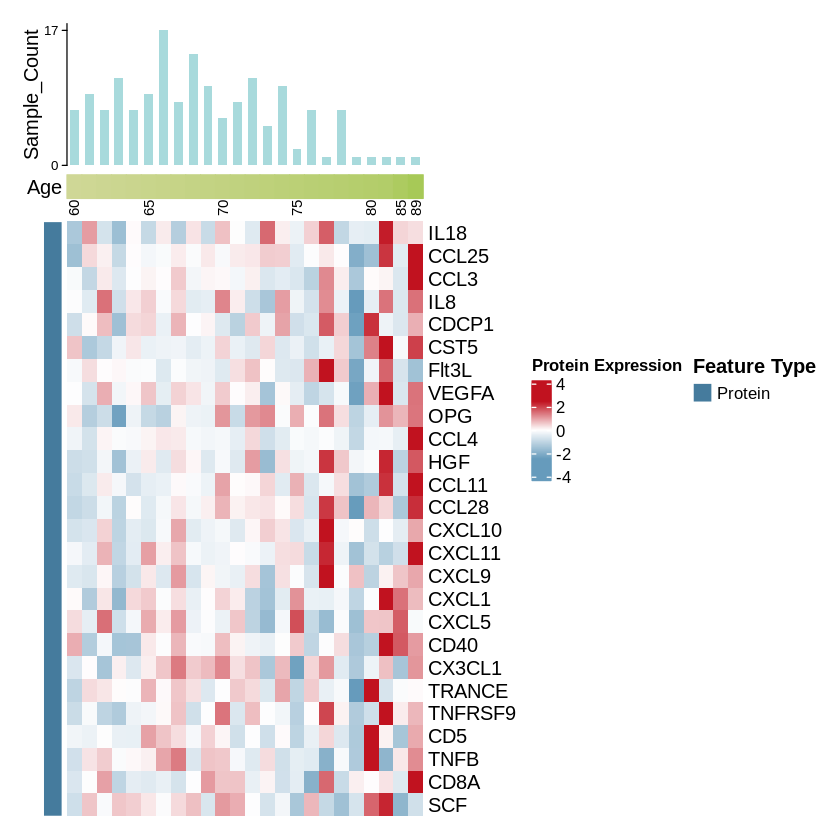

In [11]:
heatmap_data <- merged_data[, !(colnames(merged_data) %in% c("Sample_ID", "Age"))]

# 1. **Ensure Age is sorted in order**
sorted_indices <- order(merged_data$Age, na.last = FALSE)
heatmap_data_sorted <- heatmap_data[sorted_indices, , drop = FALSE]
age_sorted <- merged_data$Age[sorted_indices]

# 2. **Remove NA and synchronize Age**
valid_rows <- complete.cases(heatmap_data_sorted)  # Ensure all rows have no NA
heatmap_data_sorted <- heatmap_data_sorted[valid_rows, , drop = FALSE]
age_sorted <- age_sorted[valid_rows]

# 3. **Convert DataFrame and merge Age**
heatmap_data_sorted <- as.data.frame(heatmap_data_sorted)
heatmap_data_sorted$Age <- age_sorted

# 4. **Group by Age and calculate median**
heatmap_data_grouped <- heatmap_data_sorted %>%
  group_by(Age) %>%
  summarise(across(everything(), median, na.rm = TRUE)) %>%
  ungroup() %>%
  arrange(Age)  # Ensure Age is still in ascending order

# Separate data BEFORE transposin
age_sorted <- heatmap_data_grouped$Age
heatmap_data_grouped_matrix <- as.matrix(select(heatmap_data_grouped, -Age))

# 7. **Create Feature Type vector** - All features are Protein type
# feature_types <- rep("Protein", ncol(heatmap_data_grouped))
# # 5. **Separate data by Feature Type BEFORE transposing**
# protein_cols <- which(feature_types == "Protein")

# protein_data_original <- heatmap_data_grouped_matrix[, protein_cols, drop = FALSE]

# # Transpose each data type separately
# protein_data <- t(protein_data_original)
protein_data_original <- heatmap_data_grouped_matrix
protein_data <- t(protein_data_original)

# 6. **Calculate sample counts for each Age group**
age_counts <- as.data.frame(table(merged_data$Age))  # Count original Age occurrences
colnames(age_counts) <- c("Age", "Count")  # Ensure clear column names
age_counts$Age <- as.numeric(as.character(age_counts$Age))  # Convert to numeric

# 7. **Merge sample counts to age_sorted (after grouping)**
age_counts_sorted <- age_counts[match(age_sorted, age_counts$Age), ]  # Ensure order matches
sample_counts <- ifelse(is.na(age_counts_sorted$Count), 0, age_counts_sorted$Count)  # Avoid NA

# 8. **Ensure sample_counts length matches heatmap columns**
# sample_counts should have the same length as the number of age groups in the heatmap
stopifnot(length(sample_counts) == length(age_sorted))

# 8. **Update Age Labels to show (n=sample_count)**
age_labels <- ifelse(
  age_sorted %in% c(min(age_sorted), max(age_sorted)) | age_sorted %% 5 == 0, 
  # paste0(as.character(age_sorted), " (n=", sample_counts, ")"),  # Format: "Age (n=X)" - commented out
  as.character(age_sorted),  # Show only age without sample count
  ""  # Keep blank elsewhere
)

# 23. **Apply z-score normalization to each Feature Type separately**
# Function to calculate z-score for each feature (row)
zscore_data <- function(data_matrix) {
  zscore_matrix <- t(apply(data_matrix, 1, function(x) {
    x_mean <- mean(x, na.rm = TRUE)
    x_sd <- sd(x, na.rm = TRUE)
    
    # Handle constant values (zero variance)
    if (is.na(x_sd) || x_sd == 0) {
      return(rep(0, length(x)))
    }
    
    return((x - x_mean) / x_sd)
  }))
  return(zscore_matrix)
}

# Apply z-score normalization to each Feature Type
protein_data_zscore <- zscore_data(protein_data)

# Create appropriate color functions for z-score data
protein_zscore_range <- range(protein_data_zscore, na.rm = TRUE)

# Create symmetric color scales centered at 0
max_protein_abs <- max(abs(protein_zscore_range))

# Truncate to 2.5 standard deviations for better visualization
protein_limit <- min(max_protein_abs, 2.5)

# Color functions for z-score data with truncation
protein_col_fun <- colorRamp2(
  breaks = seq(-protein_limit, protein_limit, length.out = 100),
  colors = colorRampPalette(c("#669bbc", "white", "#c1121f"))(100)
)

# Create breaks for legends (use truncated limits)
protein_breaks <- round(seq(-protein_limit, protein_limit, length.out = 7), 2)

age_col_fun <- colorRamp2(
  breaks = c(min(age_sorted), max(age_sorted)),
  colors = c("#cfd796", "#a7c957")
)

# Protein heatmap - 添加top_annotation
protein_heatmap <- Heatmap(
  protein_data_zscore,
  name = "Protein Expression",
  #cluster_rows = TRUE, change to same order
    cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = TRUE,
  show_column_names = TRUE,
  col = protein_col_fun,
  row_dend_reorder = FALSE,
  top_annotation = HeatmapAnnotation(
    Age = anno_simple(age_sorted, col = age_col_fun),
    Age_Label = anno_text(age_labels, gp = gpar(fontsize = 9), rot = 90),
    annotation_name_side = "left"
  ),
  left_annotation = rowAnnotation(
    Feature_Type = anno_block(
      gp = gpar(fill = "#457b9d", col = "white"),
      width = unit(4, "mm")
    )
  ),
  rect_gp = gpar(col = NA),
  border = FALSE
)

# 25. **Create legends for separate heatmaps**
protein_legend <- Legend(
  title = "Protein Expression", 
  col_fun = protein_col_fun,
  at = protein_breaks,
  labels = protein_breaks
)

feature_type_legend_separate <- Legend(
  title = "Feature Type",
  title_gp = gpar(fontsize = 12, fontface = "bold"),
#   at = c("Cytokine stimulus pair", "Protein"),
#   legend_gp = gpar(fill = c("#e63946", "#457b9d"))
# )
  at = c("Protein"),
  legend_gp = gpar(fill = c("#457b9d"))
)
# 26. **Create sample count bar chart annotation**
sample_count_anno <- HeatmapAnnotation(
  Sample_Count = anno_barplot(
    sample_counts,
    gp = gpar(fill = "#a8dadc", col = NA, lwd = 0),
    height = unit(3, "cm"),
    axis_param = list(
      at = c(0, max(sample_counts)),
      labels = c("0", max(sample_counts)),
      gp = gpar(fontsize = 8)
    ),
    border = FALSE  # Remove border
  ),
  annotation_name_side = "left"  # Move annotation name to left
)
# 27. **Combine separate heatmaps vertically with sample count annotation**
heatmap_combined_separate <- sample_count_anno %v% protein_heatmap

#28. **Save separate version to PDF**
pdf("/vol/projects/yzhang/BCG_prime/05_multi-omics_model/output/heatmap/heatmap_prime_zscore_same_order_feature(500fg)_gender.pdf", width = 18, height = 15, onefile = FALSE)

draw(
  heatmap_combined_separate,
  show_heatmap_legend = TRUE,
  show_annotation_legend = TRUE,
  annotation_legend_list = list(feature_type_legend_separate),
  heatmap_legend_side = "right",
  annotation_legend_side = "right",
  padding = unit(c(15, 15, 15, 15), "mm")
)

dev.off()

#29. **Display separate version on screen**
draw(
  heatmap_combined_separate,
  show_heatmap_legend = TRUE,
  show_annotation_legend = TRUE,
  annotation_legend_list = list(feature_type_legend_separate),
  heatmap_legend_side = "right",
  annotation_legend_side = "right",
  padding = unit(c(5, 5, 5, 5), "mm")
)


pdf 
  2

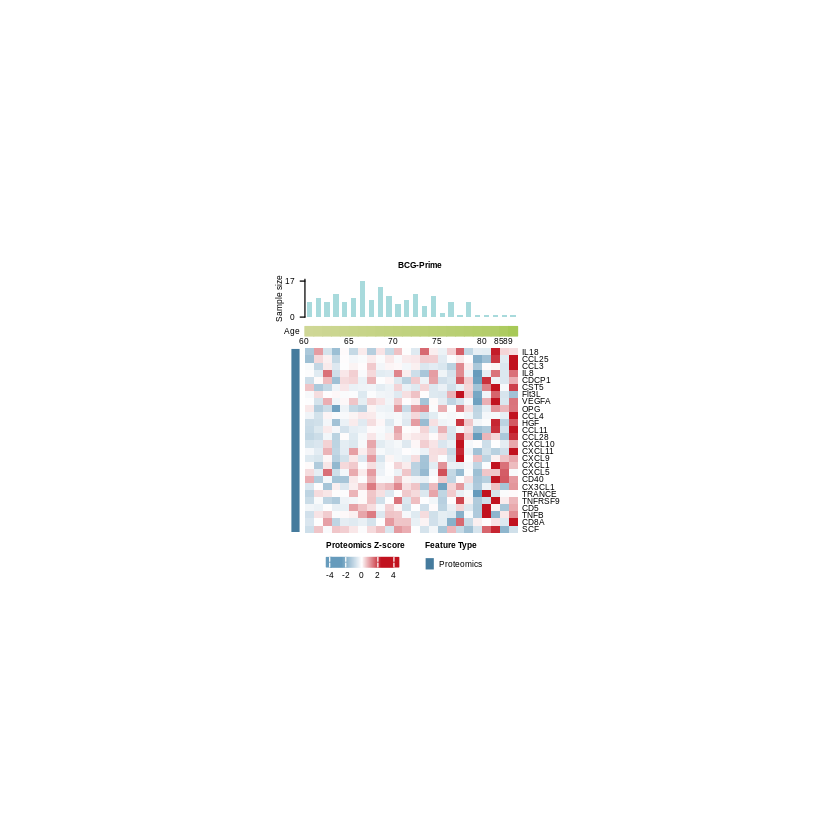

In [12]:
###nature style
# ========== Change 1: Add one line (Nature-style font, 6 pt) ==========
font_pt <- 5
row_height_mm <- 1.5 
heatmap_width_mm <- 45

#age_labels[age_sorted == 70] <- "" #hide 70，overlap in the fig
# ========== Change 2: Add/update these in Heatmap() ==========
protein_heatmap <- Heatmap(
  protein_data_zscore,
  name = "Proteomics Z-score",
  height = unit(nrow(protein_data_zscore) * row_height_mm, "mm"),
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = TRUE,
  show_column_names = TRUE,
  row_names_gp = gpar(fontsize = font_pt),              # ADD
  column_names_gp = gpar(fontsize = font_pt),           # ADD
  col = protein_col_fun,
  row_dend_reorder = FALSE,
    width = unit(heatmap_width_mm, "mm"),
  top_annotation = HeatmapAnnotation(
    Age = anno_simple(age_sorted, col = age_col_fun, height = unit(2, "mm")),
    Age_Label = anno_text(age_labels, gp = gpar(fontsize = font_pt), rot = 0),  
    annotation_name_side = "left",
    annotation_name_gp = gpar(fontsize = font_pt)
  ),
  left_annotation = rowAnnotation(
    Feature_Type = anno_block(
      gp = gpar(fill = "#457b9d", col = "white"),
      width = unit(2, "mm")
    )
  ),
  rect_gp = gpar(col = NA),
  border = FALSE,
  heatmap_legend_param = list(                          # ADD this block
    title_gp = gpar(fontsize = font_pt, fontface = "bold"),
    labels_gp = gpar(fontsize = font_pt),
      direction = "horizontal",
    legend_width = unit(15, "mm"),          
    grid_height = unit(2, "mm")    
  )
)


# ========== Change 3: Feature Type legend font ==========
feature_type_legend_separate <- Legend(
  title = "Feature Type",
  title_gp = gpar(fontsize = font_pt, fontface = "bold"),
  at = c("Proteomics"),
  legend_gp = gpar(fill = c("#457b9d")),
  labels_gp = gpar(fontsize = font_pt),
    grid_height = unit(2, "mm"),    
  grid_width = unit(2, "mm")    
)


# ========== Change 4: Sample count axis font ==========
sample_count_anno <- HeatmapAnnotation(
   `Sample size` = anno_barplot(
    sample_counts,
    gp = gpar(fill = "#a8dadc", col = NA, lwd = 0),
    height = unit(0.8, "cm"),
    axis_param = list(
      at = c(0, max(sample_counts)),
      labels = c("0", max(sample_counts)),
      gp = gpar(fontsize = font_pt)
    ),
    border = FALSE
  ),
  annotation_name_side = "left",
  annotation_name_gp = gpar(fontsize = font_pt)
)

heatmap_combined_separate <- sample_count_anno %v% protein_heatmap

# ========== Change 5: PDF size (Nature double-column) ==========
pdf("/vol/projects/yzhang/BCG_prime/05_multi-omics_model/output/heatmap/heatmap_prime_zscore_same_feature(500fg)_nature_gender.pdf", width = 3.46, height = 3.5, onefile = FALSE)

draw(
  heatmap_combined_separate,
  column_title = "BCG-Prime",                    
  column_title_side = "top",
  column_title_gp = gpar(fontsize = font_pt, fontface = "bold"),
  show_heatmap_legend = TRUE,
  show_annotation_legend = TRUE,
   annotation_legend_list = list(feature_type_legend_separate),
  heatmap_legend_side = "bottom",
  annotation_legend_side = "bottom",
  merge_legends = TRUE,
  legend_title_gp = gpar(fontsize = font_pt, fontface = "bold"),
  legend_labels_gp = gpar(fontsize = font_pt),
  legend_grid_height = unit(2, "mm"),
  legend_grid_width = unit(2, "mm"),
)

dev.off()

#29. **Display separate version on screen**
draw(
  heatmap_combined_separate,
  column_title = "BCG-Prime",                    
  column_title_side = "top",
  column_title_gp = gpar(fontsize = font_pt, fontface = "bold"),
  show_heatmap_legend = TRUE,
  show_annotation_legend = TRUE,
   annotation_legend_list = list(feature_type_legend_separate),
  heatmap_legend_side = "bottom",
  annotation_legend_side = "bottom",
    merge_legends = TRUE
)

In [40]:
save.image("/vol/projects/yzhang/BCG_prime/05_multi-omics_model/output/heatmap/heatmap_prime_zscore_same_feature(500fg)_gender.Rdata")

In [28]:
out_prime <- list(
  protein_data = protein_data,
  sample_counts      = sample_counts,
  age_sorted         = age_sorted,
  age_labels         = age_labels,
  age_col_fun        = age_col_fun
)
saveRDS(out_prime, "/vol/projects/yzhang/BCG_prime/05_multi-omics_model/output/heatmap/heatmap_prime_nature.rds")